In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [2]:
def log_pz(z):
    return -0.5 * z**2 - 0.5 * jnp.log(2 * jnp.pi)

x = f(z) = a * z + b (example of invertible and diff. trasf.)

In [3]:
def f(z, a, b):
    return a * z + b

z = f^{-1}(x) = (x - b)/a 

In [4]:
def f_inv(x, a, b):
    return (x - b) / a

p(x)= p(z) abs(det J of f^{-1})
but we have to notice that:
(det J of f^{-1}) = (det J of f)^{-1}

in our case:
J of f^{-1} = d x/ dz = - 1/a
J of f = d z/d x = a

In [5]:
def log_det_jacobian(a):
    return jnp.log(jnp.abs(a)) 

def log_px(x, a, b):
    z = f_inv(x, a, b)
    return log_pz(z) - log_det_jacobian(a)

the heart of the nf:
p(x) = p(z) abs (det J f)^{-1}
in this case
p(x) = p(z) (abs a)^{-1}
so 
log p(x) = log p(z) - log (abs (a))

In [6]:
def log_px(x, a, b):
    z = f_inv(x, a, b)
    return log_pz(z) - log_det_jacobian(a)

sampling:

In [7]:
key = jax.random.PRNGKey(0)
z_samples = jax.random.normal(key, shape=(10000,))

a = 2.0
b = 7.5

x_samples = f(z_samples, a, b)

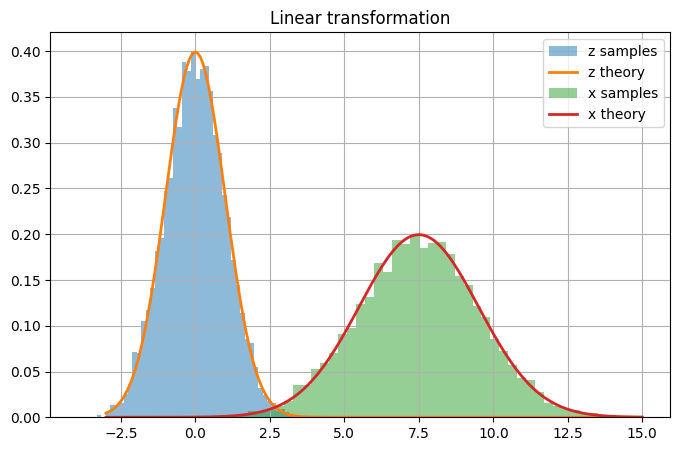

In [8]:
xs = jnp.linspace(-3, 15, 200)
px = jnp.exp(log_px(xs, a, b)) # we can compute the density of x using the change of variables formula!


plt.figure(figsize=(8,5))
plt.title("Linear transformation")
plt.hist(z_samples, bins=50, density=True, alpha=0.5, label="z samples")
plt.plot(xs, jnp.exp(log_pz(xs)), label="z theory", linewidth=2)
plt.hist(x_samples, bins=50, density=True, alpha=0.5, label="x samples")
plt.plot(xs, px, label="x theory", linewidth=2)
plt.legend()
plt.grid()
plt.show()